In [1]:
import cv2
import numpy as np
from patchify import patchify
from keras.utils import normalize
import tensorflow as tf
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt

In [2]:
IMG_PATH = r"T:\Orthopaedics\Lab Imaging Data\mmazur\NT_Validation_Study4\Rb41 (Redo CSA)\Rb41_Right_A\40X_TIFF\Rb41_RA_40X_003.tif"
img = cv2.imread(IMG_PATH, 0)

In [3]:
TARGET_SIZE = (1440, 1024)  # (width, height) for cv2

def resize_img(img_path: str, is_mask: bool = False) -> np.ndarray:
    """
    Load and resize an image to TARGET_SIZE (1440×1024).

    For regular images: converts to greyscale, resizes with INTER_AREA.
    For masks: loads as greyscale, resizes with INTER_NEAREST to preserve labels.

    Args:
        img_path: path to the image file
        is_mask:  if True, use nearest-neighbour interpolation

    Returns:
        np.ndarray of shape (1024, 1440) dtype uint8

    Raises:
        ValueError: if the image cannot be read
    """
    
    img = cv2.imread(img_path, 0)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    # # Convert to greyscale if multi-channel
    # if img.ndim == 3:
    #     if img.shape[2] == 4:
    #         img = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    #     else:
    #         img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Only resize if not already target size
    h, w = img.shape[:2]
    if (w, h) == TARGET_SIZE:
        return img

    img = cv2.resize(img, TARGET_SIZE)
    return img

In [4]:
def center_crop(img, patch_size):
    h, w = img.shape[:2]
    crop_h = (h // patch_size) * patch_size
    crop_w = (w // patch_size) * patch_size
    start_h = (h - crop_h) // 2
    start_w = (w - crop_w) // 2
    return img[start_h:start_h + crop_h, start_w:start_w + crop_w]

In [5]:
def _hann_fn(x, patch_size=256):
    return (1 - np.cos(2 * np.pi * x / (patch_size-1))) / 2


def get_pos(shape, i, j):
    i_max = shape[0] - 1
    j_max = shape[1] - 1
    if   i == 0     and j == 0:     return 0
    elif i == 0     and j == j_max: return 2
    elif i == i_max and j == 0:     return 6
    elif i == i_max and j == j_max: return 8
    elif i == 0:                    return 1
    elif i == i_max:                return 7
    elif j == 0:                    return 3
    elif j == j_max:                return 5
    else:                           return 4


def hann_window(pos, patch_size=256):
    half = patch_size // 2
    i, j = np.meshgrid(np.arange(patch_size), np.arange(patch_size), indexing='ij')
    c1 = (i <= half) & (j <= half)
    c2 = (i > half)  & (j <  half)
    c3 = (i <  half) & (j >  half)
    c4 = ~c1 & ~c2 & ~c3
    s = np.zeros((patch_size, patch_size), dtype=float)
    hi = _hann_fn(i.astype(float), patch_size)
    hj = _hann_fn(j.astype(float), patch_size)
    if pos == 0:
        s[c1]=1;             s[c2]=hi[c2];          s[c3]=hj[c3];          s[c4]=hi[c4]*hj[c4]
    elif pos == 1:
        s[c1]=hj[c1];        s[c2]=hi[c2]*hj[c2];   s[c3]=hj[c3];          s[c4]=hi[c4]*hj[c4]
    elif pos == 2:
        s[c1]=hj[c1];        s[c2]=hi[c2]*hj[c2];   s[c3]=1;               s[c4]=hi[c4]
    elif pos == 3:
        s[c1]=hi[c1];        s[c2]=hi[c2];           s[c3]=hi[c3]*hj[c3];   s[c4]=hi[c4]*hj[c4]
    elif pos == 4:
        s[c1]=hi[c1]*hj[c1]; s[c2]=hi[c2]*hj[c2];   s[c3]=hi[c3]*hj[c3];   s[c4]=hi[c4]*hj[c4]
    elif pos == 5:
        s[c1]=hi[c1]*hj[c1]; s[c2]=hi[c2]*hj[c2];   s[c3]=hi[c3];          s[c4]=hi[c4]
    elif pos == 6:
        s[c1]=hi[c1];        s[c2]=1;                s[c3]=hi[c3]*hj[c3];   s[c4]=hj[c4]
    elif pos == 7:
        s[c1]=hi[c1]*hj[c1]; s[c2]=hj[c2];          s[c3]=hi[c3]*hj[c3];   s[c4]=hj[c4]
    elif pos == 8:
        s[c1]=hi[c1]*hj[c1]; s[c2]=hj[c2];          s[c3]=hi[c3];          s[c4]=1
    return s


# ─── Recolor ──────────────────────────────────────────────────────────────────

def recolor(pred):
    """BGW: 0=black, 1=grey(128), 2=white(255)"""
    out = np.zeros(pred.shape, dtype=np.uint8)
    out[pred == 1] = 128
    out[pred == 2] = 255
    return np.stack([out, out, out], axis=-1)

In [6]:
def clahe(img, lower, upper, img_mean, img_std):
    brightness = np.mean(img)
    a = 1
    
    if (brightness < img_mean) and (brightness >= lower):
        z = ((img_mean - brightness) / img_std)
        a = 1/(2*(1-np.log(z)))
    elif (brightness > img_mean) and (brightness <= upper):
        z = ((brightness - img_mean) / img_std)
        a = (1-np.log(z))/2
            
    img = cv2.convertScaleAbs(img, alpha=a, beta=0)
    
    return img

In [7]:
def patch_clahe(img, lower, upper, img_mean, img_std, patch_size=2):
    step = patch_size // 2
    patches = patchify(img, (patch_size, patch_size), step=step)
    n_rows, n_cols = patches.shape[:2]
    batch_img = np.zeros(img.shape, dtype=float)
    
    for i in range(n_rows):
        for j in range(n_cols):
            
            patch = patches[i,j,:,:]
            
            brightness = np.mean(patch)
            a = 1
            
            if (brightness < img_mean) and (brightness >= lower):
                z = ((img_mean - brightness) / img_std)
                a = 1/(2*(1-np.log(z)))
            elif (brightness > img_mean) and (brightness <= upper):
                z = ((brightness - img_mean) / img_std)
                a = (1-np.log(z))/2
            
            patch = cv2.convertScaleAbs(patch, alpha=a, beta=0)
            
            pos = get_pos((n_rows, n_cols), i, j)
            hann = hann_window(pos, patch_size)
            adj = patch * hann

            i_start = i * step
            j_start = j * step
            batch_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += adj
    
    return batch_img

In [8]:
def segment_image(img_path, model, patch_size=256, cropped_dir=None, log=None):
    step = patch_size // 2  # 50% overlap

    # Resize
    img = resize_img(img_path, is_mask=False)

    # Center crop
    img_crop = center_crop(img, patch_size)
    crop_h, crop_w = img_crop.shape[:2]

    # Save cropped image
    # if cropped_dir:
    #     Path(cropped_dir).mkdir(parents=True, exist_ok=True)
    #     stem = Path(img_path).stem
    #     cv2.imwrite(str(Path(cropped_dir) / f"{stem}_cropped.tif"), img_crop)

    # Patchify (still uint8 at this point)
    patches = patchify(img_crop, (patch_size, patch_size), step=step)
    n_rows, n_cols = patches.shape[:2]

    pred_img = np.zeros((crop_h, crop_w), dtype=float)

    for i in range(n_rows):
        for j in range(n_cols):
            
            patch = patches[i,j,:,:]
            patch = normalize(patch)
            patch = np.expand_dims(patch, axis=(0,3))
            pred = model.predict(patch)
            pred = np.argmax(pred, axis=3)
            pred = pred[0,:,:]

            pos = get_pos((n_rows, n_cols), i, j)
            hann = hann_window(pos, patch_size)
            adj = pred * hann

            i_start = i * step
            j_start = j * step
            pred_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += adj

    pred_img = np.round(pred_img).astype(int)
    result = recolor(pred_img)
    
    return result, img_crop

In [9]:
def clahe_segment_image(img_path, model, patch_size=256, cropped_dir=None, log=None):
    step = patch_size // 2
    
    img = resize_img(img_path, is_mask=False)

    img_crop = center_crop(img, patch_size)
    crop_h, crop_w = img_crop.shape[:2]

    patches = patchify(img_crop, (patch_size, patch_size), step=step)
    n_rows, n_cols = patches.shape[:2]

    pred_img = np.zeros((crop_h, crop_w), dtype=float)
    pred2_img = np.zeros((crop_h, crop_w), dtype=float)
    clahe_img = np.zeros((crop_h, crop_w), dtype=float)
    p_clahe_img = np.zeros((crop_h, crop_w), dtype=float)
    brightness_img = np.zeros((crop_h, crop_w), dtype=float)
    
    lower = np.mean(img_crop) - (np.std(img_crop) / 2)
    upper = np.mean(img_crop) + (np.std(img_crop) / 2)
    img_mean = np.mean(img_crop)
    img_std = np.std(img_crop)

    for i in range(n_rows):
        for j in range(n_cols):
            patch = patches[i,j,:,:]
            clahe_patch = clahe(patch, lower, upper, img_mean, img_std)
            p_clahe_patch = patch_clahe(patch, lower, upper, img_mean, img_std)
            brightness_patch = np.full((patch_size, patch_size), np.mean(patch))
            
            patch = normalize(clahe_patch)
            patch = np.expand_dims(patch, axis=(0,3))
            pred = model.predict(patch)
            pred = np.argmax(pred, axis=3)
            pred = pred[0,:,:]

            patch2 = normalize(p_clahe_patch)
            patch2 = np.expand_dims(patch2, axis=(0,3))
            pred2 = model.predict(patch2)
            pred2 = np.argmax(pred2, axis=3)
            pred2 = pred2[0,:,:]
            
            pos = get_pos((n_rows, n_cols), i, j)
            hann = hann_window(pos, patch_size)
            adj = pred * hann
            adj2 = pred2 * hann
            clahe_patch = clahe_patch * hann
            p_clahe_patch = p_clahe_patch * hann
            brightness_patch = brightness_patch * hann

            i_start = i * step
            j_start = j * step
            
            pred_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += adj
            pred2_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += adj2
            clahe_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += clahe_patch
            p_clahe_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += p_clahe_patch
            brightness_img[i_start:i_start + patch_size, j_start:j_start + patch_size] += brightness_patch

    pred_img = np.round(pred_img).astype(int)
    result = recolor(pred_img)

    pred2_img = np.round(pred2_img).astype(int)
    result2 = recolor(pred2_img)
    
    return result, clahe_img, brightness_img, p_clahe_img, result2

In [10]:
def dice_coef(y_true, y_pred, smooth: float = 1.0):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def iou_coef(y_true, y_pred, smooth: float = 1.0):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def combined_loss(y_true, y_pred):
    """Weighted combination of dice loss and binary cross-entropy."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * K.mean(bce)

custom_objects = {
    'dice_coef': dice_coef,
    'dice_loss': dice_loss,
    'iou_coef': iou_coef,
    'combined_loss': combined_loss,
}

model = tf.keras.models.load_model(
    str(r"C:\Users\mazurm\deepaxon\models\rb_v1.keras"),
    custom_objects=custom_objects,
    compile=False
)

In [11]:
pred, img_crop = segment_image(IMG_PATH, model)

1/1 [==============================] - 0s 80ms/step


In [12]:
clahe_pred, clahe_img, brightness, p_clahe_img, pred2 = clahe_segment_image(IMG_PATH, model)

1/1 [==============================] - 0s 87ms/step


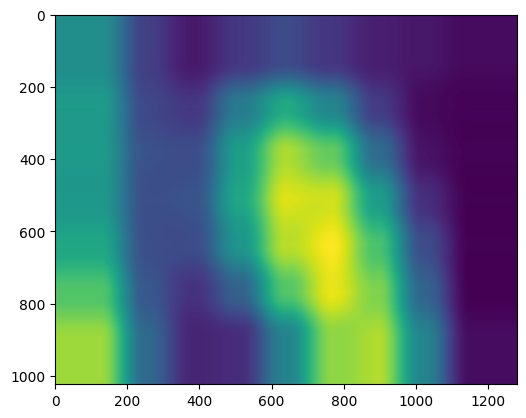

In [13]:
plt.imshow(brightness)

In [14]:
brightness.min()

78.33309348078382

In [15]:
brightness.max()

187.0118688946326

In [16]:
for i in range(0,100, 10):
    print(f"{i}%: {np.percentile(brightness, i)}")

0%: 78.33309348078382
10%: 81.27923360339345
20%: 87.57253898901837
30%: 95.96233933016326
40%: 103.43227878377748
50%: 111.0418241033429
60%: 126.0020325921346
70%: 136.25224885911743
80%: 148.86960950977348
90%: 168.6549445014068


In [17]:
np.mean(img_crop)

120.21839218139648

In [18]:
print(np.mean(img_crop) - np.std(img_crop))
print(np.mean(img_crop) + np.std(img_crop))

70.1289576402506
170.30782672254236


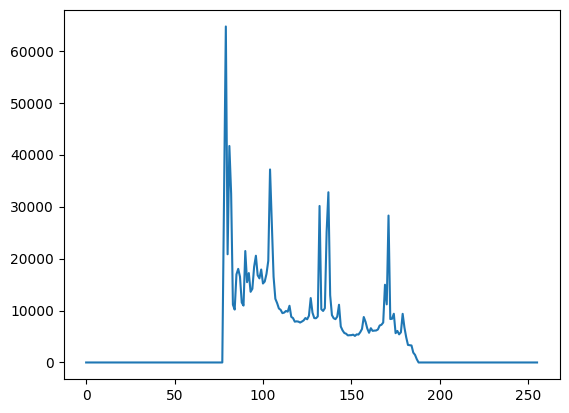

In [19]:
pixels = brightness.flatten()
hist, bins = np.histogram(pixels, bins=256, range=(0, 255))
plt.plot(hist)
plt.show()

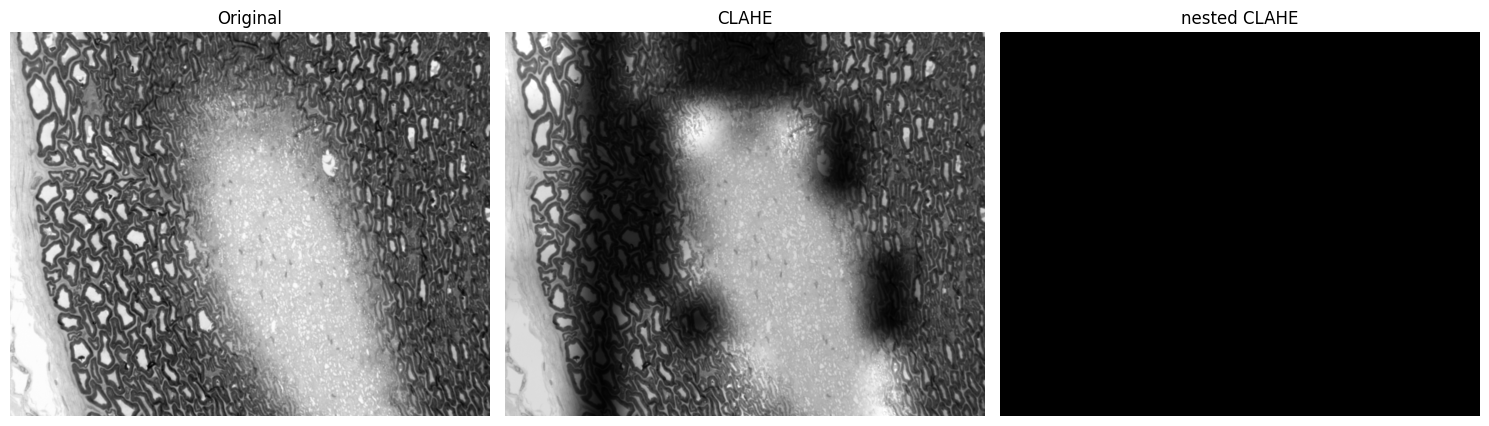

In [20]:
fig, ax = plt.subplots(1, 3)

fig.set_size_inches(15, 5)

ax[0].imshow(img_crop, 'gray')
ax[0].set_title("Original")
ax[0].axis('off') # Hide axis ticks

ax[1].imshow(clahe_img, 'gray')
ax[1].set_title("CLAHE")
ax[1].axis('off') # Hide axis ticks

ax[2].imshow(p_clahe_img, 'gray')
ax[2].set_title("nested CLAHE")
ax[2].axis('off') # Hide axis ticks

plt.tight_layout()

plt.show()

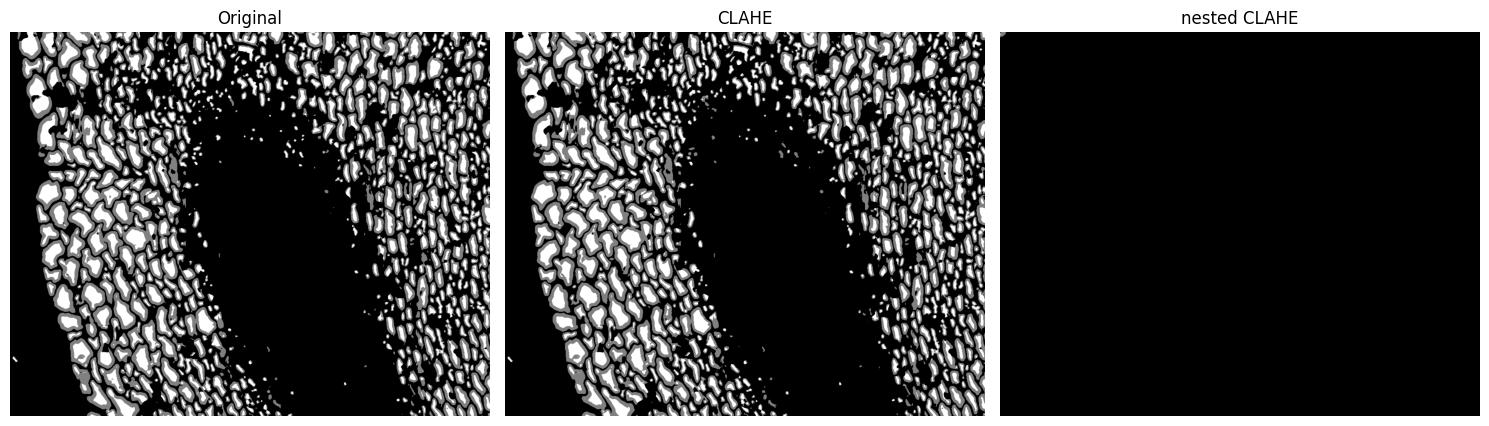

In [21]:
fig, ax = plt.subplots(1, 3)

fig.set_size_inches(15, 5)

ax[0].imshow(pred)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(clahe_pred)
ax[1].set_title("CLAHE")
ax[1].axis('off')

ax[2].imshow(pred2)
ax[2].set_title("nested CLAHE")
ax[2].axis('off')

plt.tight_layout()

plt.show()

In [22]:
np.all(pred2 == clahe_pred)

False

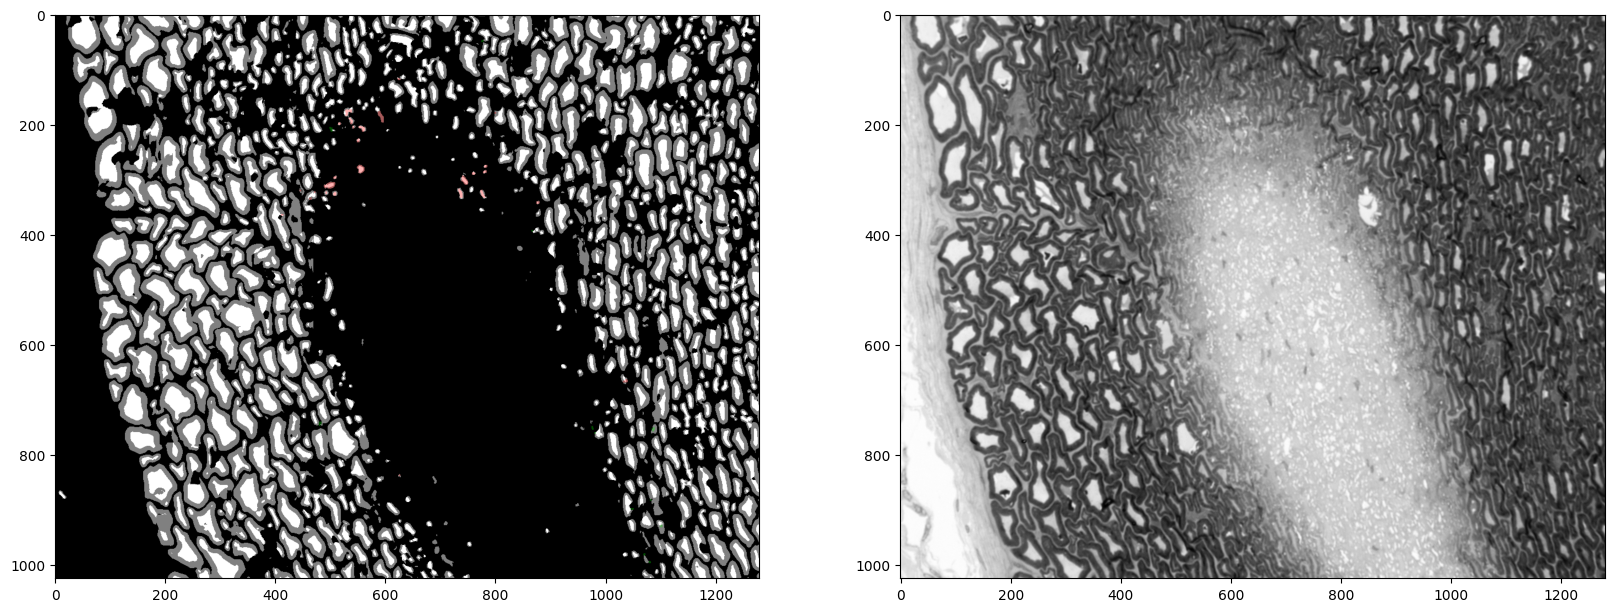

In [23]:
gray1 = cv2.cvtColor(pred, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(clahe_pred, cv2.COLOR_BGR2GRAY)

diff = gray1.astype(np.int16) - gray2.astype(np.int16)

thresh = 30

mask_pred_only  = diff > thresh
mask_clahe_only = diff < -thresh

kernel = np.ones((3, 3), np.uint8)
mask_pred_only  = cv2.morphologyEx(mask_pred_only.astype(np.uint8), cv2.MORPH_OPEN, kernel)
mask_clahe_only = cv2.morphologyEx(mask_clahe_only.astype(np.uint8), cv2.MORPH_OPEN, kernel)

mask_pred_only  = mask_pred_only.astype(bool)
mask_clahe_only = mask_clahe_only.astype(bool)

overlay = pred.copy()

overlay[mask_pred_only]  = [0, 0, 255]
overlay[mask_clahe_only] = [0, 255, 0]

result = cv2.addWeighted(pred, 0.7, overlay, 0.3, 0)

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(20, 10)

ax[0].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
ax[1].imshow(img_crop, 'gray')
plt.show()